In [11]:
from skimage import color
from skimage.util import img_as_ubyte
from skimage.util import img_as_float
from skimage.filters import prewitt
from skimage.filters import threshold_otsu
from skimage.filters import median
import time
import cv2
import numpy as np
from scipy.ndimage import correlate
from skimage import io

In [3]:
path = "/home/kkristjansson/DTU/spring2026/02515_Image_Analysis/imageAnalysisGithub/exercises/ex4-ImageFiltering/data/"


In [4]:
# Lx-4.1 Correlation between an image and a filter using scipy.ndimage.correlate

input_img = np.arange(25).reshape(5, 5)
weights = [[0, 1, 0],
           [1, 2, 1],
           [0, 1, 0]]
res_img = correlate(input_img, weights)
print(res_img)


[[  6  11  17  23  28]
 [ 31  36  42  48  53]
 [ 61  66  72  78  83]
 [ 91  96 102 108 113]
 [116 121 127 133 138]]


In [5]:
# Lx-4.2 Border handling strategies in filtering an image, including constant and reflection
reflection_img = correlate(input_img, weights, mode='reflect')
constant_img = correlate(input_img, weights, mode='constant', cval = 10)
zero_padding_img = correlate(input_img, weights, mode='constant', cval = 0)

print("Reflection border handling:\n", reflection_img)
print("Constant border handling:\n", constant_img)


Reflection border handling:
 [[  6  11  17  23  28]
 [ 31  36  42  48  53]
 [ 61  66  72  78  83]
 [ 91  96 102 108 113]
 [116 121 127 133 138]]
Constant border handling:
 [[ 26  20  25  30  40]
 [ 36  36  42  48  54]
 [ 61  66  72  78  79]
 [ 86  96 102 108 104]
 [ 96 110 115 120 110]]


In [6]:
# Lx-4.3 Implement and apply a mean filter to an image

def mean_filter(input_img, kernel_size):

    filter = np.matrix(np.ones((kernel_size, kernel_size)))
    filter = filter.astype(np.int64)

    weights = filter / np.sum(filter)

    out_img = correlate(input_img, weights, mode='reflect')
    return out_img

    

mean_filter(input_img, 3)

array([[ 2,  2,  3,  4,  5],
       [ 5,  5,  6,  8,  8],
       [10, 11, 12, 13, 13],
       [15, 15, 17, 18, 18],
       [18, 19, 20, 21, 22]])

In [7]:
# Lx-4.4 Implement a median filtter to an image using skimage.filters.median

def median_filter(input_img, kernel_size):
    filter = np.ones((kernel_size, kernel_size))
    out_img = median(input_img, filter)
    return out_img
median_filter(input_img, 3)



array([[ 1,  2,  3,  4,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14],
       [15, 16, 17, 18, 19],
       [20, 20, 21, 22, 23]])

In [8]:
# Lx-4.5 Implement a Gaussian filter to an image using skimage.filters.gaussian

def gaussian_filter(input_img, kernel_size, sigma):
    

SyntaxError: incomplete input (1168319317.py, line 4)

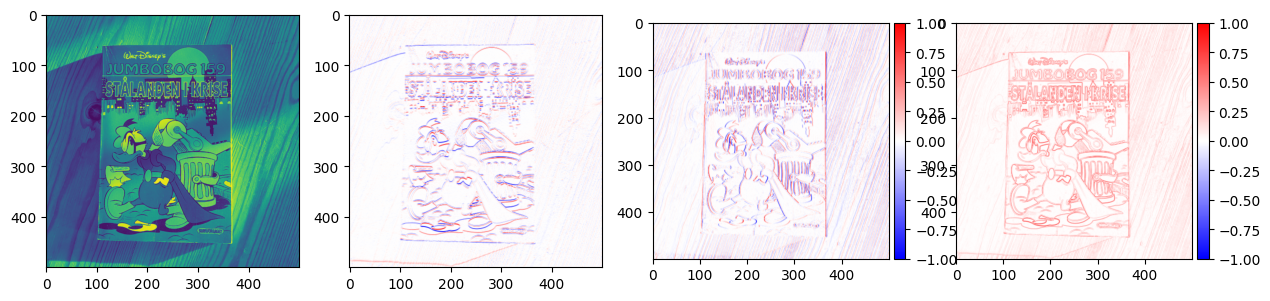

In [15]:
# Lx-4.9 Use the Prewitt to extract horizontal and vertical edges and their combined magnitude

from skimage.filters import prewitt_h, prewitt_v, prewitt
from matplotlib import pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
img = io.imread(path + "donald_1.png")
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
horizontal_edges = prewitt_h(img_gray)
vertical_edges = prewitt_v(img_gray)
combined_edges = prewitt(img_gray)

fig, ax = plt.subplots(nrows = 1, ncols = 4, figsize = (15, 5))
ax[0].imshow(img_gray)
ax[1].imshow(horizontal_edges, cmap = 'bwr', vmin = -1, vmax = 1)

im = ax[2].imshow(vertical_edges, cmap = 'bwr', vmin = -1, vmax = 1)
divider = make_axes_locatable(ax[2])
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(im, cax=cax)

im = ax[3].imshow(combined_edges, cmap = 'bwr', vmin = -1, vmax = 1)
divider = make_axes_locatable(ax[3])
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(im, cax=cax)

plt.show()

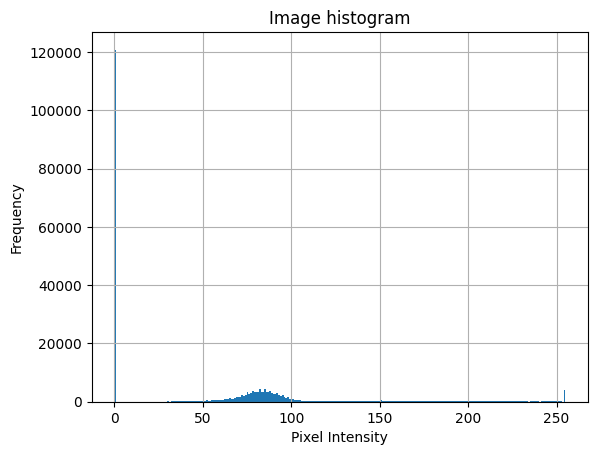

/tmp/ipykernel_275400/3539490484.py:16: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(img_gray)
/tmp/ipykernel_275400/3539490484.py:17: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


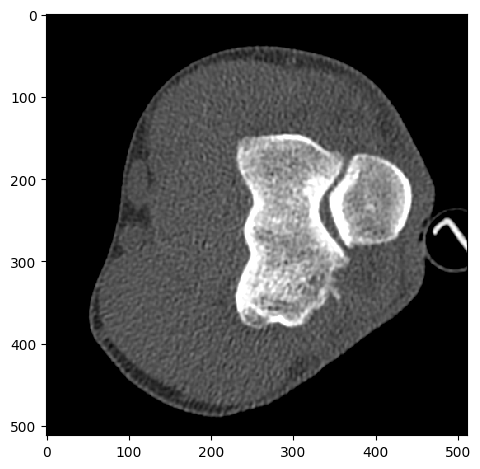

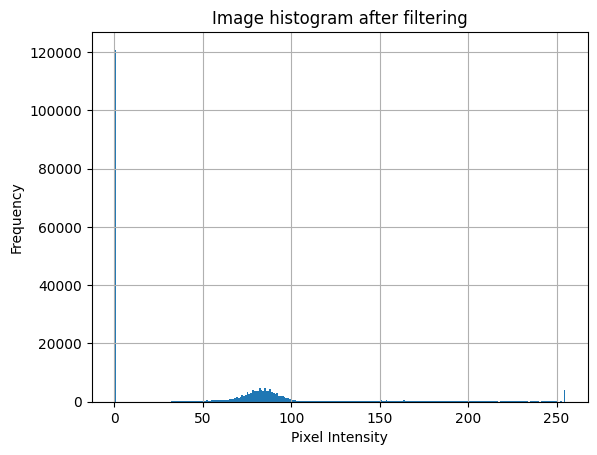

/home/kkristjansson/DTU/spring2026/02515_Image_Analysis/02515_Image_Analysis_Github/exam_practice_sets/utils.py:32: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


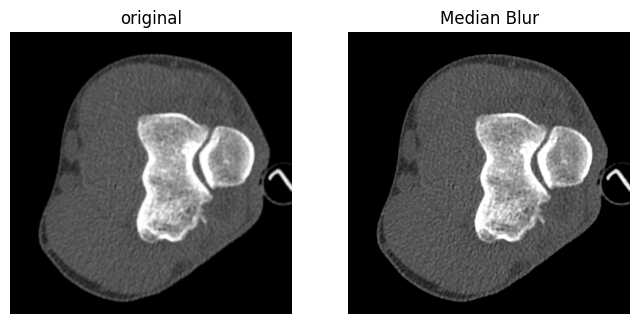

/home/kkristjansson/DTU/spring2026/02515_Image_Analysis/02515_Image_Analysis_Github/exam_practice_sets/utils.py:32: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


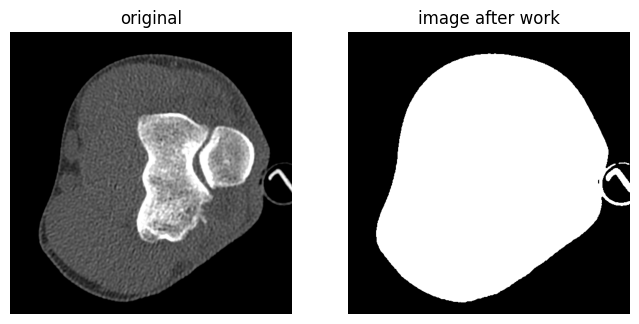

In [39]:
# Lx-4.10 Estimatea thershold in an edge image to create a binary image reflecting the significant edges in an image
from utils import plot_comparison

# read in the image and convert to grayscale
img = io.imread(path + "ElbowCTSlice.png")
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# histogram to see the pattern of pixel intensities in the image to help us choose between gaussian and median blur
plt.hist(img_gray.ravel(),bins=256) 
plt.title("Image histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.grid()
plt.show()

io.imshow(img_gray)
io.show()


# filter the image for noise
from skimage.filters import gaussian
from scipy.ndimage import median_filter
median_blur = median_filter(img_gray, size = 3, mode = 'constant', cval = 0)
gaussian_blur = gaussian(median_blur, sigma = 1)

plt.hist(median_blur.ravel(),bins=256)
plt.title("Image histogram after filtering")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.grid()
plt.show()  

# Lets find the outliers


# bin_no = 50
# count = h[0][bin_no]
# print(f"There are {count} values in bin {bin_no}")

# bin_left = h[1][bin_no]
# bin_right = h[1][bin_no+1]
# print(f"Bin edges: {bin_left} to the {bin_right}")


plot_comparison(gaussian_blur, median_blur,  "Median Blur")

gradient = prewitt(gaussian_blur)

thresh = threshold_otsu(gradient)

bin_img = gaussian_blur > thresh

plot_comparison(img_gray, bin_img, "image after work")
